# LungLens — Baseline Training (Frozen Backbone)

**Goal:** establish an honest baseline — ResNet-18 with **all conv layers frozen**, training only the final `fc` classifier head (~2K trainable params).

- Dataset: COVID-19 Radiography (4 classes) from Kaggle
- No augmentation, single LR (1e-3), fixed 10 epochs, no scheduler
- Outputs: `results/baseline_history.json`, confusion matrix, loss/acc curves

> Run this on a **GPU runtime** (Colab T4). Expected time: ~25–30 min.

In [1]:
!pip install -q pytorch-lightning torchmetrics opendatasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 24.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.7 MB/s eta 0:00:00


In [2]:
import json, time, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, models, transforms
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
import torchmetrics

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
pl.seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path("saved_models"); MODELS_DIR.mkdir(exist_ok=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cuda


In [3]:
# --- Download dataset (asks for your Kaggle username + API key on first run) ---
import opendatasets as od

DATASET_URL = "https://www.kaggle.com/datasets/raunakgola/radiography-dataset-covid"
if not Path("radiography-dataset-covid").exists():
    od.download(DATASET_URL)
else:
    print("Dataset already downloaded, skipping...")

# Locate Train/Test folders regardless of exact nesting
TRAIN_DIR = next(Path("radiography-dataset-covid").rglob("Train"))
TEST_DIR = TRAIN_DIR.parent / "Test"
print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)
print("Classes:", sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir()))

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/raunakgola/radiography-dataset-covid


100%|██████████| 745M/745M [00:12<00:00, 64.6MB/s] 



Train: radiography-dataset-covid/COVID-19_Radiography_Dataset/Train
Test : radiography-dataset-covid/COVID-19_Radiography_Dataset/Test
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [4]:
# --- Data: NO augmentation for the baseline (eval transforms everywhere) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH_SIZE = 128
NUM_WORKERS = 2

full_train = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)
CLASS_NAMES = full_train.classes
NUM_CLASSES = len(CLASS_NAMES)

# 90/10 train/val split (seeded — identical split is reused in the finetune notebook)
idx = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(SEED)).tolist()
n_val = int(0.1 * len(full_train))
val_idx, train_idx = idx[:n_val], idx[n_val:]
train_ds = Subset(full_train, train_idx)
val_ds = Subset(full_train, val_idx)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {CLASS_NAMES}")

Train: 15237 | Val: 1693 | Test: 4235
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


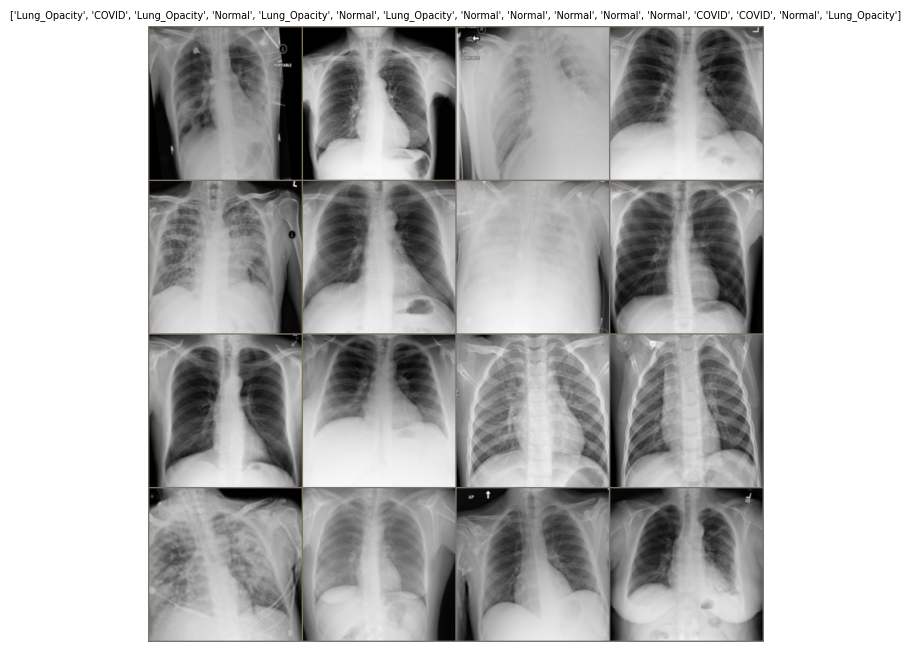

In [5]:
# --- Sanity check: show 16 images ---
import torchvision

images, labels = next(iter(train_dl))
grid = torchvision.utils.make_grid(images[:16], nrow=4)
inp = grid.numpy().transpose((1, 2, 0))
inp = np.clip(np.array(IMAGENET_STD) * inp + np.array(IMAGENET_MEAN), 0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(inp)
plt.title([CLASS_NAMES[x] for x in labels[:16]], fontsize=7)
plt.axis("off")
plt.show()

In [6]:
# --- LightningModule: frozen backbone, train fc head only ---
class LungLensBaseline(pl.LightningModule):
    def __init__(self, num_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for p in self.model.parameters():
            p.requires_grad = False  # freeze everything
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)  # new head, trainable
        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.train_acc(out, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.val_acc(out, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True)

    def test_step(self, batch, _):
        x, y = batch
        out = self(x)
        loss = self.criterion(out, y)
        self.test_acc(out, y)
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_acc", self.test_acc, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        # ONLY the fc head parameters — nothing else has requires_grad=True
        return optim.Adam(self.model.fc.parameters(), lr=self.hparams.lr)


model = LungLensBaseline(num_classes=NUM_CLASSES)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.3f}%)")
print(f"Frozen params:    {total-trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Total params:     11,178,564
Trainable params: 2,052  (0.018%)
Frozen params:    11,176,512


In [7]:
# --- Train: fixed 10 epochs, no scheduler, no early stopping (honest baseline) ---
EPOCHS = 10

checkpoint_cb = ModelCheckpoint(
    dirpath=MODELS_DIR, filename="baseline-best",
    monitor="val_acc", mode="max", save_top_k=1,
)

trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    precision="16-mixed" if DEVICE == "cuda" else "32-true",
    callbacks=[checkpoint_cb],
    logger=CSVLogger("lightning_logs", name="baseline"),
    deterministic=True,
)

start = time.time()
trainer.fit(model, train_dl, val_dl)
train_minutes = (time.time() - start) / 60
print(f"\nTraining took {train_minutes:.1f} min | Best val_acc: {checkpoint_cb.best_model_score:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 11.2 M                                                                                       
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.714                                                                     
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.



Training took 11.4 min | Best val_acc: 0.8476


In [8]:
# --- Evaluate best checkpoint on the held-out test set ---
test_metrics = trainer.test(model, test_dl, ckpt_path="best")[0]
print(test_metrics)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/saved_models/baseline-best.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/saved_models/baseline-best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8510035276412964     │
│         test_loss         │    0.4167824685573578     │
└───────────────────────────┴───────────────────────────┘

{'test_loss': 0.4167824685573578, 'test_acc': 0.8510035276412964}


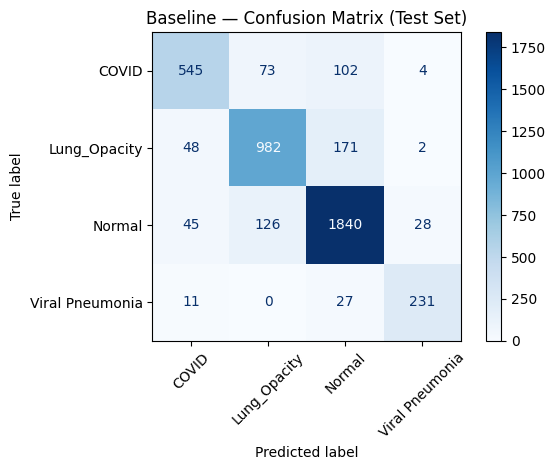

                 precision    recall  f1-score   support

          COVID       0.84      0.75      0.79       724
   Lung_Opacity       0.83      0.82      0.82      1203
         Normal       0.86      0.90      0.88      2039
Viral Pneumonia       0.87      0.86      0.87       269

       accuracy                           0.85      4235
      macro avg       0.85      0.83      0.84      4235
   weighted avg       0.85      0.85      0.85      4235



In [9]:
# --- Confusion matrix + classification report ---
best = LungLensBaseline.load_from_checkpoint(checkpoint_cb.best_model_path)
best.eval().to(DEVICE)

preds_list, labels_list = [], []
with torch.no_grad():
    for X, y in test_dl:
        out = best(X.to(DEVICE))
        preds_list.append(out.argmax(1).cpu().numpy())
        labels_list.append(y.numpy())
preds = np.concatenate(preds_list); labels = np.concatenate(labels_list)

cm = confusion_matrix(labels, preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Baseline — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(labels, preds, target_names=CLASS_NAMES))

Saved results/baseline_history.json

BASELINE TEST ACCURACY: 85.10%


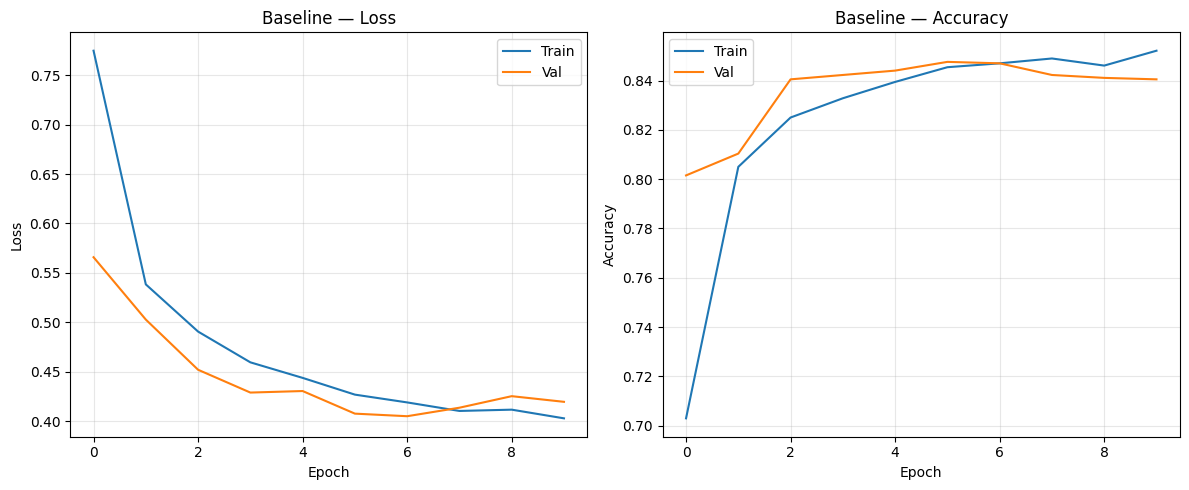

In [10]:
# --- Save history + plots for transparency ---
metrics_csv = Path(trainer.logger.log_dir) / "metrics.csv"
mdf = pd.read_csv(metrics_csv)
by_epoch = mdf.groupby("epoch").last()

history = {
    "mode": "baseline",
    "model": "resnet18 (frozen backbone, fc head only)",
    "dataset": "COVID-19 Radiography (Kaggle: raunakgola/radiography-dataset-covid)",
    "class_names": CLASS_NAMES,
    "seed": SEED,
    "epochs_run": int(by_epoch.index.max()) + 1,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "augmentation": False,
    "scheduler": None,
    "early_stopping": False,
    "total_params": total,
    "trainable_params": trainable,
    "train_minutes": round(train_minutes, 1),
    "train_loss": by_epoch["train_loss"].dropna().tolist(),
    "train_acc": by_epoch["train_acc"].dropna().tolist(),
    "val_loss": by_epoch["val_loss"].dropna().tolist(),
    "val_acc": by_epoch["val_acc"].dropna().tolist(),
    "best_val_acc": float(checkpoint_cb.best_model_score),
    "test_acc": float(test_metrics["test_acc"]),
    "test_loss": float(test_metrics["test_loss"]),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}

with open(RESULTS_DIR / "baseline_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved results/baseline_history.json")
print(f"\nBASELINE TEST ACCURACY: {history['test_acc']*100:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history["train_loss"], label="Train"); ax1.plot(history["val_loss"], label="Val")
ax1.set(title="Baseline — Loss", xlabel="Epoch", ylabel="Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history["train_acc"], label="Train"); ax2.plot(history["val_acc"], label="Val")
ax2.set(title="Baseline — Accuracy", xlabel="Epoch", ylabel="Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_curves.png", dpi=150)
plt.show()

In [11]:
# --- Zip artifacts to download back into the local repo ---
with zipfile.ZipFile("baseline_artifacts.zip", "w") as zf:
    for p in RESULTS_DIR.glob("baseline_*"):
        zf.write(p)
print("Created baseline_artifacts.zip — download it and extract into your local lung-lens/ folder")
# In Colab you can also run:  from google.colab import files; files.download('baseline_artifacts.zip')

Created baseline_artifacts.zip — download it and extract into your local lung-lens/ folder


In [12]:
!find results saved_models lightning_logs -type f

results/baseline_confusion_matrix.png
results/baseline_history.json
results/baseline_curves.png
saved_models/baseline-best.ckpt
lightning_logs/baseline/version_0/hparams.yaml
lightning_logs/baseline/version_0/metrics.csv


In [13]:
with zipfile.ZipFile("baseline_artifacts.zip", "w") as zf:
    for p in Path("results").glob("baseline_*"):
        zf.write(p)

from google.colab import files
files.download("baseline_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

!cp baseline_artifacts.zip /content/drive/MyDrive/

Mounted at /content/drive
